In [1]:
import jax.numpy as np
import qutip
import qutip_jax
import matplotlib.pyplot as plt
from qutip import basis, tensor,Qobj, mcsolve
from scipy import integrate

In [2]:
#parameters
omega_r = 2 * np.pi * 50 #MHz
omega_max = omega_r
omega_R = 2.5 * omega_r #MHz
Dta = 2 * np.pi * 1200 #MHz
T_p = 16 * np.pi * Dta/(3 * omega_max**2)
T_c = np.pi/omega_r
tmax = T_c * 2 + T_p
V_dd = 2 * np.pi * 500 #MHz
V_vdws = 2 * np.pi * 1 #MHz
tau_c = 548
tau_p = 0.131
tau_R = 505
gamma_c = 1/tau_c
gamma_p = 1/tau_p
gamma_R = 1/tau_R

In [3]:
#time list
tlist = np.linspace(0, tmax, 1000)

with qutip.CoreOptions(default_dtype="jax"):
	#control atom states
	g = basis(2,0) #|0>     
	r = basis(2,1) #|1>

	#dagger
	g_dag = g.dag()  # <0|
	r_dag = r.dag()  # <1|

	#target atom states
	A = basis(4,0) 
	B = basis(4,1)
	P = basis(4,2)
	R = basis(4,3)

	#dagger
	A_dag = A.dag()
	B_dag = B.dag()
	P_dag = P.dag()
	R_dag = R.dag()

In [4]:
from qutip_jax.qobjevo import JaxJitCoeff

In [5]:
#control field
# we probably cannot use logic condition here: https://docs.jax.dev/en/latest/control-flow.html
def Omega_c(t, T_c, omega_r, T_p, tmax):
    return np.heaviside(T_c-t, 1) * omega_r + np.heaviside(t-T_c-T_p, 1) * omega_r * np.heaviside(tmax-t, 1)

In [6]:
omega_c = JaxJitCoeff(Omega_c,args={
	"T_c":T_c,
	"omega_r":omega_r,
	"T_p":T_p,
	"tmax":tmax
}, static_argnames = ("omega_r","T_c", "T_p", "tmax",)) 

In [7]:
#probe field
def Omega_p(t, T_c, omega_max, T_p):
    return np.heaviside(t-T_c,1) * np.heaviside(T_c+T_p-t,1) * omega_max * (np.sin(np.pi * (t-T_c)/T_p))**2


In [8]:
omega_p = JaxJitCoeff(Omega_p,args={
	"T_c":T_c,
	"omega_max":omega_max,
	"T_p":T_p
}, static_argnames = ("omega_max","T_c", "T_p")) 

In [9]:
#integrate 
def integrand(t):
    return Omega_p(t,T_c,omega_max,T_p)**2
integral_value, error = integrate.quad(integrand, 0, tmax)

print(f"积分值: {integral_value/(2 * np.pi * Dta):.6f}")
print(f"积分误差: {error:.2e}")


积分值: 1.000000
积分误差: 7.88e-06


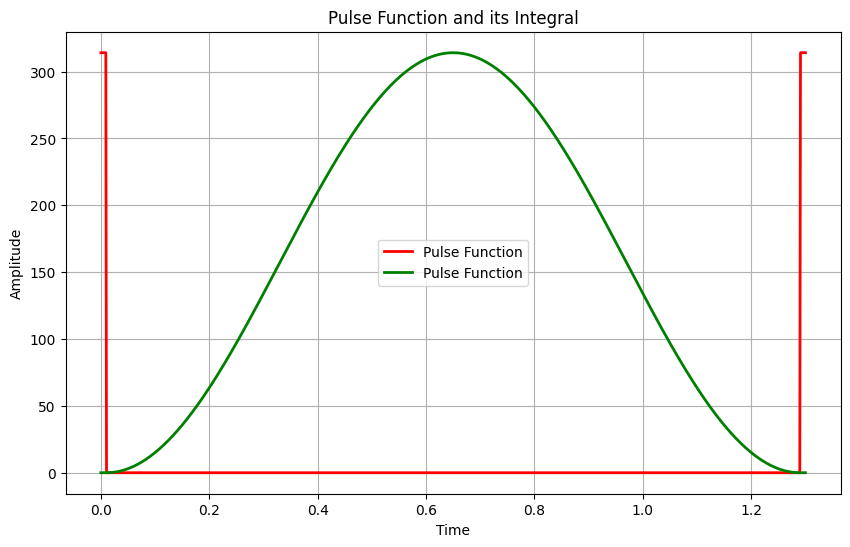

In [10]:
# 可视化函数和积分
t_plot = np.linspace(0, tmax, 1000)
pulse_valuesp = [Omega_p(t,T_c,omega_max,T_p) for t in t_plot]
pulse_valuesc = [Omega_c(t,T_c,omega_r,T_p,tmax) for t in t_plot]
#pulse_values = [Omega_c for t in t_plot]
plt.figure(figsize=(10, 6))
#plt.plot(t_plot, pulse_values, 'b-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesc, 'r-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesp, 'g-', linewidth=2, label='Pulse Function')

plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
hrr = r * r_dag
hRR = R * R_dag

In [12]:
L_c = np.sqrt(gamma_c) * (g * r_dag)

In [13]:
L_P = np.sqrt(gamma_p) * (A * P_dag + B * P_dag)
L_R = np.sqrt(gamma_R) * (A * R_dag + B * R_dag)

In [14]:
hc = [tensor((g*r_dag + r * g_dag)/2,Qobj(np.eye(4)),Qobj(np.eye(4))), omega_c]

In [15]:
ht_t1 = [tensor(Qobj(np.eye(2)),(P * A_dag + A * P_dag + P * B_dag + B * P_dag) + omega_R * (P * R_dag + R * P_dag)/2,Qobj(np.eye(4))), omega_p]
ht_c1 = tensor(Qobj(np.eye(2)),omega_R * (P * R_dag + R * P_dag) - Dta * P * P_dag,Qobj(np.eye(4)))


In [16]:

ht_t2 = [tensor(Qobj(np.eye(2)),Qobj(np.eye(4)),(P * A_dag + A * P_dag + P * B_dag + B * P_dag) + omega_R * (P * R_dag + R * P_dag)/2), omega_p]
ht_c2 = tensor(Qobj(np.eye(2)),Qobj(np.eye(4)),omega_R * (P * R_dag + R * P_dag) - Dta * P * P_dag)

In [17]:
# total_h = [hc, ht_t1,ht_c1, ht_t2, ht_c2]
total_h = [ht_c2, hc]

In [49]:
# def Hnhermitian(t):
    
#     h2 = V_dd * tensor(hrr, hRR, Qobj(np.eye(4))) + V_dd * tensor(hrr, Qobj(np.eye(4)), hRR) + V_vdws * tensor(Qobj(np.eye(2)), hRR, hRR)
#     h31 = -1j/2 * (L_c.dag() * L_c)
#     h32 = -1j/2 * (L_P.dag() * L_P + L_R.dag() * L_R)
#     h3 = tensor(h31, Qobj(np.eye(4)), Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), h32, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(4)), h32)
#     return h1 + h2 + h3

In [21]:
c_ops = tensor(L_c, Qobj(np.eye(4)), Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), (L_P+L_R), Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(4)), (L_R+L_P))

In [22]:
with qutip.CoreOptions(default_dtype="jax"):
	psi_0 = tensor(g,A,A)
	psi_1 = tensor(g,B,B)
	psi_2 = tensor(Qobj(np.eye(2)),A,A)
	psi_3 = tensor(Qobj(np.eye(2)),B,B)

In [23]:
from qutip import mcsolve

In [ ]:
mc = mcsolve(total_h, psi_0, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag(), psi_3*psi_3.dag()],options={"method":"diffrax"})


10.0%. Run time: 418.60s. Est. time left: 00:01:02:47


In [ ]:
print(mc.expect[1][999])


0.9918857900920113


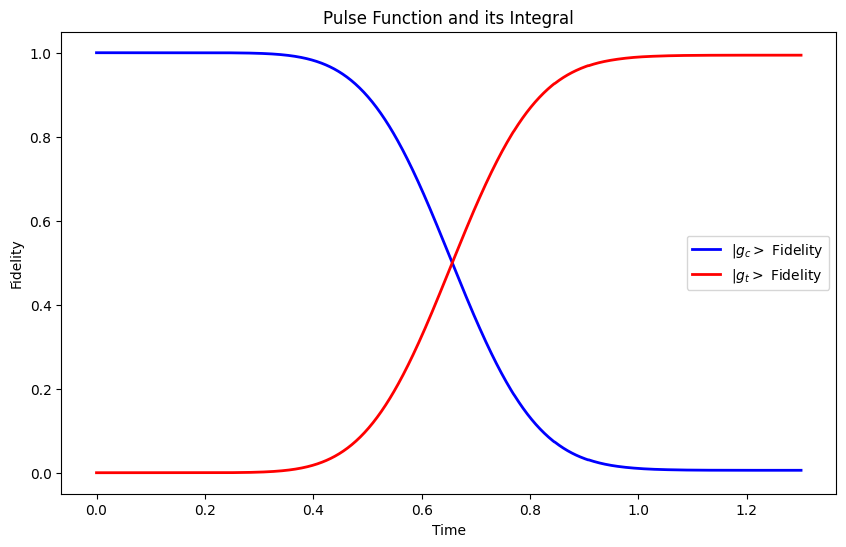

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc.expect[2],'-b',lw=2,label='$|g_c>$ Fidelity')

plt.plot(tlist,mc.expect[3],'-r',lw=2,label='$|g_t>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()